# ADSBLIB LIBRARY VALIDATION


In [10]:
import ctypes
import random
import math
import statistics

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import pyModeS as pms

_native_decode = getattr(pms, "decode", None)


def _decode_compat(message, timestamps=None):
    if _native_decode is not None:
        return _native_decode(message, timestamps=timestamps) if timestamps is not None else _native_decode(message)

    if isinstance(message, list):
        even_hex, odd_hex = message
        if timestamps is None:
            timestamps = [0.0, 1.0]
        position = pms.adsb.position(
            even_hex, odd_hex, timestamps[0], timestamps[1]
        )
        if position is None:
            return [None]
        return [{"latitude": position[0], "longitude": position[1]}]

    message = str(message)
    payload = int(message[8:22], 16)
    typecode = pms.adsb.typecode(message)
    decoded = {"typecode": typecode}

    if typecode in range(1, 5):
        decoded["callsign"] = pms.adsb.callsign(message)
    elif typecode in range(5, 9):
        movement = (payload >> 44) & 0x7F
        track = (payload >> 36) & 0x7F
        decoded["movement"] = movement
        decoded["track"] = track * 360.0 / 128.0
    elif typecode in range(9, 19):
        decoded["altitude"] = pms.adsb.altitude(message)
    elif typecode == 19:
        speed, track, vertical_rate, _ = pms.adsb.velocity(message)
        decoded["subtype"] = (payload >> 48) & 0x7
        decoded["groundspeed"] = speed
        decoded["track"] = track
        decoded["vertical_rate"] = vertical_rate

    return decoded


if _native_decode is None:
    pms.decode = _decode_compat

In [11]:
from pathlib import Path
import platform

_project_dir = Path.cwd()
_lib_name = "adsblib.dylib" if platform.system() == "Darwin" else "adsblib.so"
_lib_path = (_project_dir / _lib_name).resolve()
if not _lib_path.exists():
    _lib_path = (_project_dir.parent / _lib_name).resolve()

if not _lib_path.exists():
    raise FileNotFoundError(
        f"No se encontró {_lib_name} en {_project_dir} ni en su directorio padre. "
        f"Compila primero la librería compartida."
    )

lib = ctypes.CDLL(str(_lib_path))

ADSB_FRAME_BYTES = 14
ADSB_CALLSIGN_LEN = 8
CPR_EVEN = 0
CPR_ODD = 1

class ADSBPosition(ctypes.Structure):

    _fields_ = [
        ("icao", ctypes.c_uint32),
        ("latitude_deg", ctypes.c_double),
        ("longitude_deg", ctypes.c_double),
        ("altitude_ft", ctypes.c_int32),
        ("cpr_format", ctypes.c_int)
    ]

class ADSBIdentification(ctypes.Structure):

    _fields_ = [
        ("icao", ctypes.c_uint32),
        ("callsign", ctypes.c_char * (ADSB_CALLSIGN_LEN + 1))
    ]

class ADSBVelocity(ctypes.Structure):

    _fields_ = [
        ("icao", ctypes.c_uint32),
        ("ground_speed_kt", ctypes.c_double),
        ("track_deg", ctypes.c_double),
        ("vertical_rate_fpm", ctypes.c_int32)
    ]

class ADSBSurfacePosition(ctypes.Structure):

    _fields_ = [
        ("icao", ctypes.c_uint32),
        ("latitude_deg", ctypes.c_double),
        ("longitude_deg", ctypes.c_double),
        ("ground_speed_kt", ctypes.c_double),
        ("ground_track_deg", ctypes.c_double),
        ("cpr_format", ctypes.c_int)
    ]

lib.adsb_encode_identification.argtypes = [
    ctypes.POINTER(ADSBIdentification),
    ctypes.POINTER(ctypes.c_uint8)
]
lib.adsb_encode_identification.restype = ctypes.c_int

lib.adsb_encode_position.argtypes = [
    ctypes.POINTER(ADSBPosition),
    ctypes.POINTER(ctypes.c_uint8)
]
lib.adsb_encode_position.restype = ctypes.c_int

lib.adsb_encode_velocity.argtypes = [
    ctypes.POINTER(ADSBVelocity),
    ctypes.POINTER(ctypes.c_uint8)
]
lib.adsb_encode_velocity.restype = ctypes.c_int

lib.adsb_encode_surface_position.argtypes = [
    ctypes.POINTER(ADSBSurfacePosition),
    ctypes.POINTER(ctypes.c_uint8)
]
lib.adsb_encode_surface_position.restype = ctypes.c_int

def create_random_identification():
    icao = random.randint(0, 0xFFFFFF)
    length = random.randint(1, ADSB_CALLSIGN_LEN)
    alphabet = "ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"
    callsign = ''.join(random.choice(alphabet) for _ in range(length)).ljust(ADSB_CALLSIGN_LEN)

    msg = ADSBIdentification()
    msg.icao = icao
    msg.callsign = callsign.encode("ascii")

    frame = (ctypes.c_uint8 * ADSB_FRAME_BYTES)()
    status = lib.adsb_encode_identification(ctypes.byref(msg), frame)
    if status != 0:
        raise RuntimeError(f"adsb_encode_identification falló con código {status}")

    return frame

def encode_position(lat, lon, alt, even=True, icao=0xABCDEF):
    msg = ADSBPosition()
    msg.icao = icao
    msg.latitude_deg = float(lat)
    msg.longitude_deg = float(lon)
    msg.altitude_ft = int(alt)
    msg.cpr_format = CPR_EVEN if even else CPR_ODD

    frame = (ctypes.c_uint8 * ADSB_FRAME_BYTES)()
    status = lib.adsb_encode_position(ctypes.byref(msg), frame)
    if status != 0:
        raise RuntimeError(f"adsb_encode_position falló con código {status}")

    return frame

def encode_velocity(speed, track, vr, icao=0xABCDEF):
    msg = ADSBVelocity()
    msg.icao = icao
    msg.ground_speed_kt = float(speed)
    msg.track_deg = float(track) % 360.0
    msg.vertical_rate_fpm = int(vr)

    frame = (ctypes.c_uint8 * ADSB_FRAME_BYTES)()
    status = lib.adsb_encode_velocity(ctypes.byref(msg), frame)
    if status != 0:
        raise RuntimeError(f"adsb_encode_velocity falló con código {status}")

    return frame

def encode_surface_position(lat, lon, speed, track, even=True, icao=0xABCDEF):

    msg = ADSBSurfacePosition()
    msg.icao = icao
    msg.latitude_deg = float(lat)
    msg.longitude_deg = float(lon)
    msg.ground_speed_kt = float(speed)
    msg.ground_track_deg = float(track) % 360.0
    msg.cpr_format = CPR_EVEN if even else CPR_ODD

    frame = (ctypes.c_uint8 * ADSB_FRAME_BYTES)()
    status = lib.adsb_encode_surface_position(ctypes.byref(msg), frame)
    if status != 0:
        raise RuntimeError(f"adsb_encode_surface_position falló con código {status}")

    return frame

In [12]:
def frame_to_hex(frame):

    return ''.join(f'{b:02X}' for b in frame)

def haversine(lat1, lon1, lat2, lon2):

    R = 6371000.0

    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)

    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)

    a = (
        math.sin(dphi/2)**2
        +
        math.cos(phi1)
        *
        math.cos(phi2)
        *
        math.sin(dlambda/2)**2
    )

    return 2 * R * math.atan2(
        math.sqrt(a),
        math.sqrt(1-a)
    )

## TEST 1 - CRC VALIDATION

OBJECTIVE: Verify generated CRC match with pyModeS

In [13]:
from pyModeS import crc as crc_func

N = 10000

matches = 0

for _ in range(N):

    # generar mensaje desde encoder.c
    msg = create_random_identification()

    hexmsg = frame_to_hex(msg)

    crc = crc_func(hexmsg)

    if crc == 0:
        matches += 1

print(
    f"CRC success rate = {100*matches/N:.2f}%"
)

CRC success rate = 100.00%


## TEST 2 - CALLSIGN ENCODING
OBJECTIVE: Verify DF17 Type Code 1-4

In [14]:
callsigns = [
    "ECABC",
    "IBE1234",
    "RYR52AB",
    "VLG1001"
]

icao = 0xABCDEF

for original in callsigns:
    msg = ADSBIdentification()
    msg.icao = icao
    msg.callsign = original.ljust(ADSB_CALLSIGN_LEN).encode("ascii")

    frame = (ctypes.c_uint8 * ADSB_FRAME_BYTES)()
    status = lib.adsb_encode_identification(ctypes.byref(msg), frame)
    assert status == 0, f"Error codificando {original}: status={status}"

    hexmsg = frame_to_hex(frame)
    decoded_fields = pms.decode(hexmsg)
    decoded = decoded_fields.get("callsign", "")

    assert decoded.replace("_", "").strip() == original, (
        f"Callsign mismatch: esperado={original}, decodificado={decoded}"
    )

print(f"Callsign test OK: {len(callsigns)} de {len(callsigns)}")

Callsign test OK: 4 de 4


## TEST 3 - MASSIVE CPR VALIDATION

Samples: 9999
Abs error mean [m]: 2.0230865445813992
Abs error max [m]: 3.865085747297336
Abs error p95 [m]: 3.1665784111959803
Cumplimiento <= 30 m [%]: 100.0


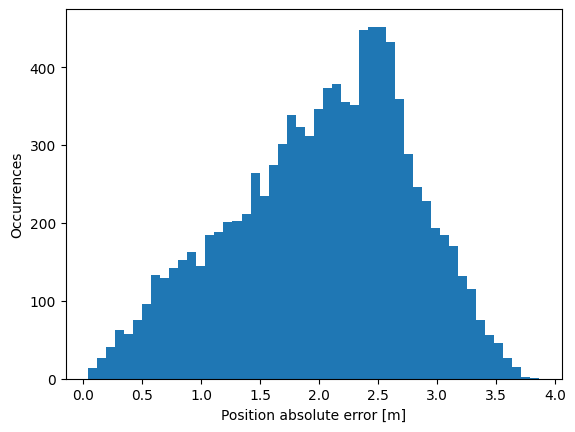

In [15]:
N = 10000

errors = []

for _ in range(N):
    lat = random.uniform(-80.0, 80.0)
    lon = random.uniform(-180.0, 180.0)
    alt = random.randint(0, 40000)

    even_frame = encode_position(lat, lon, alt, even=True)
    odd_frame = encode_position(lat, lon, alt, even=False)

    even_hex = frame_to_hex(even_frame)
    odd_hex = frame_to_hex(odd_frame)

    decoded_pair = pms.decode([even_hex, odd_hex], timestamps=[0.0, 1.0])
    decoded = decoded_pair[-1]

    if (decoded is None) or ("latitude" not in decoded) or ("longitude" not in decoded):
        continue

    lat2 = decoded["latitude"]
    lon2 = decoded["longitude"]

    if (lat2 is None) or (lon2 is None):
        continue

    error = abs(haversine(lat, lon, lat2, lon2))
    errors.append(error)

if len(errors) == 0:
    raise RuntimeError("No se pudieron decodificar pares CPR válidos")

errors = np.array(errors, dtype=float)
tol_m = 30.0
ok_pct = 100.0 * np.mean(errors <= tol_m)

print("Samples:", len(errors))
print("Abs error mean [m]:", np.mean(errors))
print("Abs error max [m]:", np.max(errors))
print("Abs error p95 [m]:", np.percentile(errors, 95))
print(f"Cumplimiento <= {tol_m:.0f} m [%]:", ok_pct)

assert ok_pct >= 99.0, "Cumplimiento de posición menor a 99%"

plt.hist(errors, bins=50)
plt.xlabel("Position absolute error [m]")
plt.ylabel("Occurrences")
plt.show()

## TEST 4 - ALTITUDE VERIFICATION
OBJECTIVE: Check Gillham/Altitude verification

In [16]:
alts = np.arange(0, 50000, 500)

alt_errors = []
decoded_count = 0

for alt in alts:
    frame = encode_position(40.0, -3.0, int(alt), even=True)
    hexmsg = frame_to_hex(frame)

    decoded = pms.decode(hexmsg)
    decoded_alt = decoded.get("altitude", None)

    if decoded_alt is None:
        continue

    decoded_count += 1
    alt_errors.append(abs(float(decoded_alt) - float(alt)))

if decoded_count == 0:
    raise RuntimeError("No se pudo decodificar altitud en ninguna muestra")

print("Samples:", decoded_count)
print("Mean altitude error [ft]:", np.mean(alt_errors))
print("Max altitude error [ft]:", np.max(alt_errors))
print("95% altitude error [ft]:", np.percentile(alt_errors, 95))

assert np.max(alt_errors) <= 25.0, "Error de altitud mayor a 25 ft"
print("Altitude test OK")

Samples: 100
Mean altitude error [ft]: 0.0
Max altitude error [ft]: 0.0
95% altitude error [ft]: 0.0
Altitude test OK


## TEST 5 - VELOCITY VERIFICATION
OBJECTIVE: Check velocity

In [17]:
N = 2000

speed_abs_errors = []
speed_pct_errors = []
track_abs_errors = []
track_pct_errors = []
vr_abs_errors = []
vr_pct_errors = []

for _ in range(N):
    speed = random.randint(50, 600)
    track = random.uniform(0.0, 360.0)
    vr = random.randint(-3000, 3000)

    frame = encode_velocity(speed, track, vr)
    hexmsg = frame_to_hex(frame)
    decoded = pms.decode(hexmsg)

    dec_speed = decoded.get("groundspeed", decoded.get("speed", decoded.get("gs", None)))
    dec_track = decoded.get("track", decoded.get("heading", None))
    dec_vr = decoded.get("vertical_rate", decoded.get("vert_rate", decoded.get("vr", None)))

    if (dec_speed is None) or (dec_track is None) or (dec_vr is None):
        continue

    speed_abs = abs(float(dec_speed) - float(speed))
    speed_abs_errors.append(speed_abs)
    speed_pct_errors.append(100.0 * speed_abs / max(float(speed), 1.0))

    dtrack = abs((float(dec_track) - float(track) + 180.0) % 360.0 - 180.0)
    track_abs_errors.append(dtrack)
    track_pct_errors.append(100.0 * dtrack / 360.0)

    vr_abs = abs(float(dec_vr) - float(vr))
    vr_abs_errors.append(vr_abs)
    vr_pct_errors.append(100.0 * vr_abs / max(abs(float(vr)), 64.0))

if len(speed_abs_errors) == 0:
    raise RuntimeError("No se pudieron decodificar campos de velocidad; revisa claves de pms.decode")

speed_abs_errors = np.array(speed_abs_errors, dtype=float)
speed_pct_errors = np.array(speed_pct_errors, dtype=float)
track_abs_errors = np.array(track_abs_errors, dtype=float)
track_pct_errors = np.array(track_pct_errors, dtype=float)
vr_abs_errors = np.array(vr_abs_errors, dtype=float)
vr_pct_errors = np.array(vr_pct_errors, dtype=float)

speed_ok_pct = 100.0 * np.mean(speed_abs_errors <= 2.0)
track_ok_pct = 100.0 * np.mean(track_abs_errors <= 2.0)
vr_ok_pct = 100.0 * np.mean(vr_abs_errors <= 64.0)

print("Samples:", len(speed_abs_errors))
print("Speed abs error mean [kt]:", np.mean(speed_abs_errors))
print("Speed abs error max [kt]:", np.max(speed_abs_errors))
print("Speed relative error mean [%]:", np.mean(speed_pct_errors))
print("Speed cumplimiento <= 2 kt [%]:", speed_ok_pct)

print("Track abs error mean [deg]:", np.mean(track_abs_errors))
print("Track abs error max [deg]:", np.max(track_abs_errors))
print("Track relative error mean [% of 360]:", np.mean(track_pct_errors))
print("Track cumplimiento <= 2 deg [%]:", track_ok_pct)

print("Vertical rate abs error mean [fpm]:", np.mean(vr_abs_errors))
print("Vertical rate abs error max [fpm]:", np.max(vr_abs_errors))
print("Vertical rate relative error mean [%]:", np.mean(vr_pct_errors))
print("Vertical rate cumplimiento <= 64 fpm [%]:", vr_ok_pct)

assert speed_ok_pct >= 99.0, "Cumplimiento de velocidad menor a 99%"
assert track_ok_pct >= 99.0, "Cumplimiento de rumbo menor a 99%"
assert vr_ok_pct >= 99.0, "Cumplimiento de vertical rate menor a 99%"
print("Velocity test OK")

Samples: 2000
Speed abs error mean [kt]: 0.462
Speed abs error max [kt]: 1.0
Speed relative error mean [%]: 0.19647012163289224
Speed cumplimiento <= 2 kt [%]: 100.0
Track abs error mean [deg]: 0.06093668268129099
Track abs error max [deg]: 0.5955316303472671
Track relative error mean [% of 360]: 0.016926856300358607
Track cumplimiento <= 2 deg [%]: 100.0
Vertical rate abs error mean [fpm]: 16.008
Vertical rate abs error max [fpm]: 32.0
Vertical rate relative error mean [%]: 2.669073010463437
Vertical rate cumplimiento <= 64 fpm [%]: 100.0
Velocity test OK


## TEST 6 - STRESS TEST
OBJECTIVE: Buscar errores ocultos

In [18]:
from pyModeS import crc as crc_func

N = 100000
failures = 0
decode_failures = 0

for _ in range(N):
    kind = random.choice(["id", "pos", "vel"])

    try:
        if kind == "id":
            frame = create_random_identification()
            hexmsg = frame_to_hex(frame)
            decoded = pms.decode(hexmsg)

        elif kind == "pos":
            lat = random.uniform(-80.0, 80.0)
            lon = random.uniform(-180.0, 180.0)
            alt = random.randint(0, 40000)
            even_frame = encode_position(lat, lon, alt, even=True)
            odd_frame = encode_position(lat, lon, alt, even=False)
            even_hex = frame_to_hex(even_frame)
            odd_hex = frame_to_hex(odd_frame)

            if crc_func(even_hex) != 0 or crc_func(odd_hex) != 0:
                failures += 1
                continue

            decoded_pair = pms.decode([even_hex, odd_hex], timestamps=[0.0, 1.0])
            decoded = decoded_pair[-1]
            hexmsg = odd_hex

        else:
            speed = random.randint(50, 600)
            track = random.uniform(0.0, 360.0)
            vr = random.randint(-3000, 3000)
            frame = encode_velocity(speed, track, vr)
            hexmsg = frame_to_hex(frame)
            decoded = pms.decode(hexmsg)

        if crc_func(hexmsg) != 0:
            failures += 1
            continue

        if decoded is None or (hasattr(decoded, "get") and decoded.get("error") is not None):
            decode_failures += 1

    except Exception:
        failures += 1

print("Total:", N)
print("Failures:", failures)
print("Decode failures:", decode_failures)
print("Success rate [%]:", 100.0 * (N - failures) / N)

assert failures == 0, "Se detectaron fallos de encoder/CRC en stress test"
print("Stress test OK")

Total: 100000
Failures: 0
Decode failures: 0
Success rate [%]: 100.0
Stress test OK


## TEST 7 - SURFACE POSITION VALIDATION
OBJECTIVE: Verify DF17 Type Code 5-8 (surface position) movement and ground track encoding against pyModeS, across the full non-linear movement-field range (stopped, sub-1 kt, up to the 175 kt open-ended code).

In [19]:
def movement_reference_speed(mov):

    """Independent re-implementation of the movement-field decode table
    (ICAO Annex 10 / DO-260B), used to cross-check pyModeS's own decode
    of adsblib's encoded output."""

    if mov == 0 or mov > 124:
        return None
    if mov == 1:
        return 0.0
    if mov == 124:
        return 175.0

    lb = [2, 9, 13, 39, 94, 109, 124]
    kts = [0.125, 1, 2, 15, 70, 100, 175]
    step = [0.125, 0.25, 0.5, 1, 2, 5]

    i = next(idx for idx, l in enumerate(lb) if l > mov)
    return kts[i - 1] + (mov - lb[i - 1]) * step[i - 1]


speed_samples = [0, 0.05, 0.5, 1.0, 5, 14.9, 18, 69, 99, 174, 175, 250, 500]
track_samples = [0, 45, 90, 140.625, 200, 270, 359.9]

tc_errors = 0
speed_errors = []
track_abs_errors = []

for speed in speed_samples:
    for track in track_samples:
        frame = encode_surface_position(37.5, -122.1, speed, track, even=True)
        hexmsg = frame_to_hex(frame)
        decoded = pms.decode(hexmsg)

        if decoded.get("typecode") not in range(5, 9):
            tc_errors += 1
            continue

        ref_speed = movement_reference_speed(decoded.get("movement"))
        if speed < 0.125:
            expected = 0.0
        elif speed >= 175:
            expected = 175.0
        else:
            expected = speed

        if ref_speed is None:
            speed_errors.append(float("inf"))
        else:
            speed_errors.append(abs(ref_speed - expected))

        dec_track = decoded.get("track")
        if dec_track is None:
            track_abs_errors.append(float("inf"))
        else:
            dtrack = abs((float(dec_track) - float(track) + 180.0) % 360.0 - 180.0)
            track_abs_errors.append(dtrack)

speed_errors = np.array(speed_errors, dtype=float)
track_abs_errors = np.array(track_abs_errors, dtype=float)

print("Type code errors:", tc_errors)
print("Movement speed abs error max [kt]:", np.max(speed_errors))
print("Ground track abs error max [deg]:", np.max(track_abs_errors))

assert tc_errors == 0, "Type code fuera de rango 5-8"
assert np.max(speed_errors) <= 6.0, "Error de velocidad de movimiento fuera de tolerancia"
assert np.max(track_abs_errors) <= (360.0 / 128.0), "Error de rumbo fuera de resolución del campo"
print("Surface position test OK")

Type code errors: 0
Movement speed abs error max [kt]: 4.0
Ground track abs error max [deg]: 0.3125
Surface position test OK


## TEST 8 - SUPERSONIC VELOCITY VALIDATION
OBJECTIVE: Verify DF17 Type Code 19 subtype 2 (supersonic ground speed, 4 kt/LSB), which adsb_encode_velocity() selects automatically once a velocity component exceeds subtype 1's +/-1022 kt range.

In [20]:
supersonic_speeds = [1100, 1500, 2000, 3000, 4000, 4088]

subtype_errors = 0
speed_abs_errors = []
track_abs_errors = []

for speed in supersonic_speeds:
    for track in [0, 90, 180, 270]:  # axis-aligned: full speed lands on one component
        frame = encode_velocity(speed, track, 0)
        hexmsg = frame_to_hex(frame)
        decoded = pms.decode(hexmsg)

        if decoded.get("subtype") != 2:
            subtype_errors += 1
            continue

        dec_speed = decoded.get("groundspeed")
        dec_track = decoded.get("track")
        if dec_speed is None or dec_track is None:
            continue

        speed_abs_errors.append(abs(float(dec_speed) - float(speed)))
        dtrack = abs((float(dec_track) - float(track) + 180.0) % 360.0 - 180.0)
        track_abs_errors.append(dtrack)

speed_abs_errors = np.array(speed_abs_errors, dtype=float)
track_abs_errors = np.array(track_abs_errors, dtype=float)

print("Subtype mismatches:", subtype_errors)
print("Speed abs error max [kt]:", np.max(speed_abs_errors))
print("Track abs error max [deg]:", np.max(track_abs_errors))

assert subtype_errors == 0, "No se seleccionó subtype 2 para velocidad supersónica"
assert np.max(speed_abs_errors) <= 8.0, "Error de velocidad fuera de tolerancia (4 kt/LSB)"
assert np.max(track_abs_errors) <= 2.0, "Error de rumbo fuera de tolerancia"
print("Supersonic velocity test OK")

Subtype mismatches: 0
Speed abs error max [kt]: 0.0
Track abs error max [deg]: 0.0
Supersonic velocity test OK


In [21]:
## TEST 9 - AIRCRAFT STATUS / EMERGENCY VALIDATION
# OBJECTIVE: Verify DF17 Type Code 28 subtype 1, emergency state, and Mode A/Gillham field.


In [22]:

class ADSBEmergency(ctypes.Structure):

    _fields_ = [
        ("icao", ctypes.c_uint32),
        ("emergency_state", ctypes.c_int),
        ("mode_a_code", ctypes.c_uint16)
    ]

lib.adsb_encode_emergency.argtypes = [
    ctypes.POINTER(ADSBEmergency),
    ctypes.POINTER(ctypes.c_uint8)
]
lib.adsb_encode_emergency.restype = ctypes.c_int


def encode_emergency(state, mode_a_code, icao=0xABCDEF):
    msg = ADSBEmergency()
    msg.icao = icao
    msg.emergency_state = int(state)
    msg.mode_a_code = int(mode_a_code)

    frame = (ctypes.c_uint8 * ADSB_FRAME_BYTES)()
    status = lib.adsb_encode_emergency(ctypes.byref(msg), frame)
    if status != 0:
        raise RuntimeError(f"adsb_encode_emergency falló con código {status}")
    return frame


def mode_a_gillham(mode_a_code):
    digits = [(mode_a_code >> shift) & 0x7 for shift in (9, 6, 3, 0)]
    a, b, c, d = digits
    return (
        ((a & 4) << 5) | ((a & 2) << 8) | ((a & 1) << 11) |
        ((b & 4) >> 1) | ((b & 2) << 2) | ((b & 1) << 5) |
        ((c & 4) << 6) | ((c & 2) << 9) | ((c & 1) << 12) |
        ((d & 4) >> 2) | ((d & 2) >> 1) | ((d & 1) << 4)
    )


for state, mode_a_code in [(0, 0o0000), (1, 0o1200), (5, 0o7500), (6, 0o7777)]:
    frame = encode_emergency(state, mode_a_code)
    message = ''.join(f'{byte:02X}' for byte in frame)
    me = int(message[8:22], 16)

    assert pms.adsb.typecode(message) == 28
    assert ((me >> 48) & 0x7) == 1
    assert ((me >> 45) & 0x7) == state
    assert ((me >> 32) & 0x1FFF) == mode_a_gillham(mode_a_code)
    assert pms.crc(message) == 0

print("Aircraft status / emergency test OK")

Aircraft status / emergency test OK


In [23]:
## TEST 10 - TARGET STATE AND STATUS VALIDATION
# OBJECTIVE: Verify DF17 Type Code 29 subtype 1 (BDS 6,2) field positions and quantization.

class ADSBTargetState(ctypes.Structure):

    _fields_ = [
        ("icao", ctypes.c_uint32),
        ("selected_altitude_ft", ctypes.c_int32),
        ("selected_altitude_source", ctypes.c_int),
        ("barometric_pressure_mbar", ctypes.c_double),
        ("selected_heading_valid", ctypes.c_bool),
        ("selected_heading_deg", ctypes.c_double),
        ("nac_p", ctypes.c_uint8),
        ("nic_baro", ctypes.c_bool),
        ("sil", ctypes.c_uint8),
        ("mode_status", ctypes.c_bool),
        ("autopilot_engaged", ctypes.c_bool),
        ("vnav_mode", ctypes.c_bool),
        ("altitude_hold_mode", ctypes.c_bool),
        ("approach_mode", ctypes.c_bool),
        ("tcas_operational", ctypes.c_bool),
        ("lnav_mode", ctypes.c_bool)
    ]

lib.adsb_encode_target_state.argtypes = [
    ctypes.POINTER(ADSBTargetState),
    ctypes.POINTER(ctypes.c_uint8)
]
lib.adsb_encode_target_state.restype = ctypes.c_int


def encode_target_state():
    msg = ADSBTargetState(
        0xABCDEF, 32000, 1, 1013.2, True, 90.0,
        9, True, 2, True, True, True, True, False, True, True
    )
    frame = (ctypes.c_uint8 * ADSB_FRAME_BYTES)()
    status = lib.adsb_encode_target_state(ctypes.byref(msg), frame)
    if status != 0:
        raise RuntimeError(f"adsb_encode_target_state falló con código {status}")
    return frame


frame = encode_target_state()
message = ''.join(f'{byte:02X}' for byte in frame)
payload = int(message[8:22], 16)

assert pms.adsb.typecode(message) == 29
assert ((payload >> 49) & 0x3) == 1
assert ((payload >> 47) & 0x1) == 1
assert ((payload >> 36) & 0x7FF) == 1001
assert ((payload >> 27) & 0x1FF) == 268
assert ((payload >> 26) & 0x1) == 1
assert ((payload >> 17) & 0x1FF) == 128
assert ((payload >> 13) & 0xF) == 9
assert ((payload >> 12) & 0x1) == 1
assert ((payload >> 10) & 0x3) == 2
assert ((payload >> 9) & 0x1) == 1
assert ((payload >> 8) & 0x1) == 1
assert ((payload >> 7) & 0x1) == 1
assert ((payload >> 6) & 0x1) == 1
assert ((payload >> 4) & 0x1) == 0
assert ((payload >> 3) & 0x1) == 1
assert ((payload >> 2) & 0x1) == 1
assert pms.crc(message) == 0

print("Target state and status test OK")

Target state and status test OK


In [24]:
## TEST 11 - AIRCRAFT OPERATIONAL STATUS VALIDATION
# OBJECTIVE: Verify DF17 Type Code 31 / BDS 6,5 field positions, version flags, and CRC.

class ADSBOperationalStatus(ctypes.Structure):

    _fields_ = [
        ("icao", ctypes.c_uint32),
        ("subtype", ctypes.c_uint8),
        ("capability_class", ctypes.c_uint16),
        ("operational_mode", ctypes.c_uint16),
        ("adsb_version", ctypes.c_uint8),
        ("nic_supplement_a", ctypes.c_bool),
        ("nac_p", ctypes.c_uint8),
        ("sil", ctypes.c_uint8),
        ("nic_baro", ctypes.c_bool),
        ("heading_reference_magnetic", ctypes.c_bool),
        ("sil_supplement", ctypes.c_bool)
    ]

lib.adsb_encode_operational_status.argtypes = [
    ctypes.POINTER(ADSBOperationalStatus),
    ctypes.POINTER(ctypes.c_uint8)
]
lib.adsb_encode_operational_status.restype = ctypes.c_int


def encode_operational_status():
    msg = ADSBOperationalStatus(
        0xABCDEF, 0, 0xA55A, 0x5AA5, 2,
        True, 12, 3, True, True, True
    )
    frame = (ctypes.c_uint8 * ADSB_FRAME_BYTES)()
    status = lib.adsb_encode_operational_status(ctypes.byref(msg), frame)
    if status != 0:
        raise RuntimeError(
            f"adsb_encode_operational_status falló con código {status}"
        )
    return frame


frame = encode_operational_status()
message = ''.join(f'{byte:02X}' for byte in frame)
payload = int(message[8:22], 16)

assert pms.adsb.typecode(message) == 31
assert ((payload >> 48) & 0x7) == 0
assert ((payload >> 32) & 0xFFFF) == 0xA55A
assert ((payload >> 16) & 0xFFFF) == 0x5AA5
assert ((payload >> 13) & 0x7) == 2
assert ((payload >> 12) & 0x1) == 1
assert ((payload >> 8) & 0xF) == 12
assert ((payload >> 4) & 0x3) == 3
assert ((payload >> 3) & 0x1) == 1
assert ((payload >> 2) & 0x1) == 1
assert ((payload >> 1) & 0x1) == 1
assert pms.crc(message) == 0

print("Aircraft operational status test OK")

Aircraft operational status test OK
